# Train a CNN on CIFAR-100

**Goal:** train a convolutional neural network (CNN) to recognize the 100 CIFAR-100 classes, then see how much we can trust its confidence.

This notebook builds on [the EDA notebook](01_cifar100_eda.ipynb). It:

1. loads the same training data and holds out a **validation set** and a **calibration set**,
2. trains a ResNet-18-style CNN with PyTorch,
3. measures accuracy, then studies **confidence**: is the model calibrated, and can **temperature scaling** fix it?
4. picks a confidence threshold that should give 95% accuracy on the images the model answers, and checks it on images it was not picked on,
5. saves the model plus logits and embeddings for the later SDM experiments.

Choose **Kernel → Restart Kernel and Run All Cells**. With the default 30 epochs, training takes about 30 minutes on an Apple M3 Pro GPU (about 1 minute per epoch), less on a recent NVIDIA GPU, and many hours on CPU only. Expect roughly 70% validation accuracy. For a quick check that everything works, set `EPOCHS = 2` first.

As in the EDA notebook, the official **test set stays untouched**. We make every modeling choice on the validation set. The test set is evaluated only in the optional last section.

In [1]:
%pip install kagglehub

Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path
import hashlib
import pickle
import tarfile
import time

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

SEED = 42
EPOCHS = 30            # set to 2 for a quick smoke test
BATCH_SIZE = 128
MAX_LR = 0.1           # peak learning rate of the one-cycle schedule
WEIGHT_DECAY = 5e-4
VAL_PER_CLASS = 25     # 25 images x 100 classes = 2,500 validation images
CAL_PER_CLASS = 25     # 25 images x 100 classes = 2,500 calibration images
TARGET_ACCURACY = 0.95 # accuracy we want on the images the model chooses to answer
EVALUATE_TEST = False  # leave False until the model is final

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

torch.manual_seed(SEED)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
print(f"PyTorch {torch.__version__}, training on: {device}")

PyTorch 2.5.1, training on: mps


## 1. Import our tools and choose settings

PyTorch builds and trains the network. We pick the fastest available device: an NVIDIA GPU (`cuda`), the Apple-silicon GPU (`mps`), or the CPU.

The settings below are the knobs you are most likely to change.

## 2. Find and load the data

This is the same loader as in the EDA notebook: unpack `data/cifar-100-python.tar.gz` if it is there, otherwise download the Kaggle mirror, and check every file against the official checksums.

In [3]:
DATA_DIR = Path("../data")  # the repository's data/ folder
data_path = DATA_DIR / "cifar-100-python"

# First run only: unpack the archive in data/, or download from Kaggle if there is none.
if not data_path.exists():
    archive_path = DATA_DIR / "cifar-100-python.tar.gz"
    if archive_path.exists():
        with tarfile.open(archive_path) as archive:
            archive.extractall(DATA_DIR, filter="data")
    else:
        data_path = Path(kagglehub.dataset_download("aakash119/cifar-100-python-tar-gz")) / "cifar-100-python"

# Make sure these are the official CIFAR-100 files before we unpickle them.
expected_md5 = {
    "train": "16019d7e3df5f24257cddd939b257f8d",
    "test": "f0ef6b0ae62326f3e7ffdfab6717acfc",
    "meta": "7973b15100ade9c7d40fb424638fde48",
}
for name, md5 in expected_md5.items():
    assert hashlib.md5((data_path / name).read_bytes()).hexdigest() == md5, f"{name} is not the official file; delete {data_path} and rerun"
print("Data ready in", data_path)

Data ready in ../data/cifar-100-python


In [4]:
def load_split(name):
    with (data_path / name).open("rb") as file:
        split = pickle.load(file, encoding="latin1")
    # (image, color channel, height, width) is the layout PyTorch expects.
    images = split["data"].reshape(-1, 3, 32, 32)
    return images, np.array(split["fine_labels"]), np.array(split["coarse_labels"])

with (data_path / "meta").open("rb") as file:
    metadata = pickle.load(file, encoding="latin1")
class_names = metadata["fine_label_names"]
group_names = metadata["coarse_label_names"]

all_images, all_labels, all_groups = load_split("train")
print(f"{len(all_images):,} training images, shape {all_images.shape[1:]}, {len(class_names)} classes")

50,000 training images, shape (3, 32, 32), 100 classes


## 3. Split the data: train, validation, calibration

Each split has one job, and no image is in more than one split:

| split | images | job |
|---|---|---|
| **training** | 45,000 | the network learns its weights from these |
| **validation** | 2,500 | watch training and report results the model and its settings were not fitted on |
| **calibration** | 2,500 | fit the confidence fixes after training: the temperature and the abstention threshold |
| **test** (official) | 10,000 | final check only, in the optional last section |

Why a separate calibration set? If we choose a confidence threshold on some images and then measure it on the *same* images, the result looks better than it really is. So we fit on calibration and check on validation.

The split is built exactly as in [the ConvNeXt baseline notebook](02_cifar100_training_baseline.ipynb): within every class, shuffle with seed 42 and take the first 25 images for validation and the next 25 for calibration. Both models therefore use the **same images** in each split, so their confidence and SDM results can be compared directly.

In [5]:
rng = np.random.default_rng(SEED)
train_idx, val_idx, cal_idx = [], [], []
for class_id in range(len(class_names)):
    shuffled = rng.permutation(np.flatnonzero(all_labels == class_id))
    val_idx.extend(shuffled[:VAL_PER_CLASS])
    cal_idx.extend(shuffled[VAL_PER_CLASS : VAL_PER_CLASS + CAL_PER_CLASS])
    train_idx.extend(shuffled[VAL_PER_CLASS + CAL_PER_CLASS :])
train_idx, val_idx, cal_idx = np.array(train_idx), np.array(val_idx), np.array(cal_idx)
assert not (set(train_idx) & set(val_idx) or set(train_idx) & set(cal_idx) or set(val_idx) & set(cal_idx))

x_train, y_train = all_images[train_idx], all_labels[train_idx]
x_val, y_val, g_val = all_images[val_idx], all_labels[val_idx], all_groups[val_idx]
x_cal, y_cal = all_images[cal_idx], all_labels[cal_idx]

pd.Series({
    "training images": len(x_train),
    "validation images": len(x_val),
    "calibration images": len(x_cal),
    "images per class (val / cal)": f"{np.bincount(y_val).min()} / {np.bincount(y_cal).min()}",
}, name="split").to_frame()

,split
training images,45000
validation images,2500
calibration images,2500
images per class (val / cal),25 / 25


## 4. Prepare the pixels: normalization and augmentation

**Normalization.** We shift and scale each color channel to mean 0 and standard deviation 1. The statistics come from the training split only, so no validation information leaks into training.

**Augmentation.** A CNN with millions of parameters can memorize 45,000 images. To make it learn general features instead, every training batch is randomly changed a little:

- **random crop**: pad the image by 4 pixels, then cut a random 32 × 32 window (a small shift),
- **horizontal flip**: mirror half the images left to right.

The class does not change: a shifted or mirrored apple is still an apple. Validation images are never augmented.

To keep training fast, the whole dataset sits on the device as 8-bit integers, and we normalize and augment each batch there.

In [6]:
channel_mean = torch.tensor(x_train.mean(axis=(0, 2, 3)) / 255, dtype=torch.float32, device=device).view(1, 3, 1, 1)
channel_std = torch.tensor(x_train.std(axis=(0, 2, 3)) / 255, dtype=torch.float32, device=device).view(1, 3, 1, 1)

def to_device(images, labels):
    return torch.from_numpy(images).to(device), torch.from_numpy(labels).long().to(device)

train_images, train_labels = to_device(x_train, y_train)
val_images, val_labels = to_device(x_val, y_val)
cal_images, cal_labels = to_device(x_cal, y_cal)

def normalize(batch):
    return (batch.float() / 255 - channel_mean) / channel_std

def augment(batch, pad=4):
    # Random crop: pad, then pick a random 32 x 32 window for each image.
    n, _, h, w = batch.shape
    padded = F.pad(batch, (pad, pad, pad, pad), mode="reflect")
    top = torch.randint(0, 2 * pad + 1, (n, 1, 1), device=batch.device)
    left = torch.randint(0, 2 * pad + 1, (n, 1, 1), device=batch.device)
    rows = top + torch.arange(h, device=batch.device).view(1, h, 1)
    cols = left + torch.arange(w, device=batch.device).view(1, 1, w)
    batch = padded[torch.arange(n, device=batch.device).view(n, 1, 1), :, rows, cols].permute(0, 3, 1, 2)
    # Horizontal flip for a random half of the batch.
    flip = torch.rand(n, 1, 1, 1, device=batch.device) < 0.5
    return torch.where(flip, batch.flip(3), batch)

print("channel mean:", channel_mean.flatten().cpu().numpy().round(3))
print("channel std: ", channel_std.flatten().cpu().numpy().round(3))

channel mean: [0.507 0.487 0.441]
channel std:  [0.267 0.256 0.276]


Let's check the augmentation by eye. Each row shows one training image (left) and five random augmented versions of it.

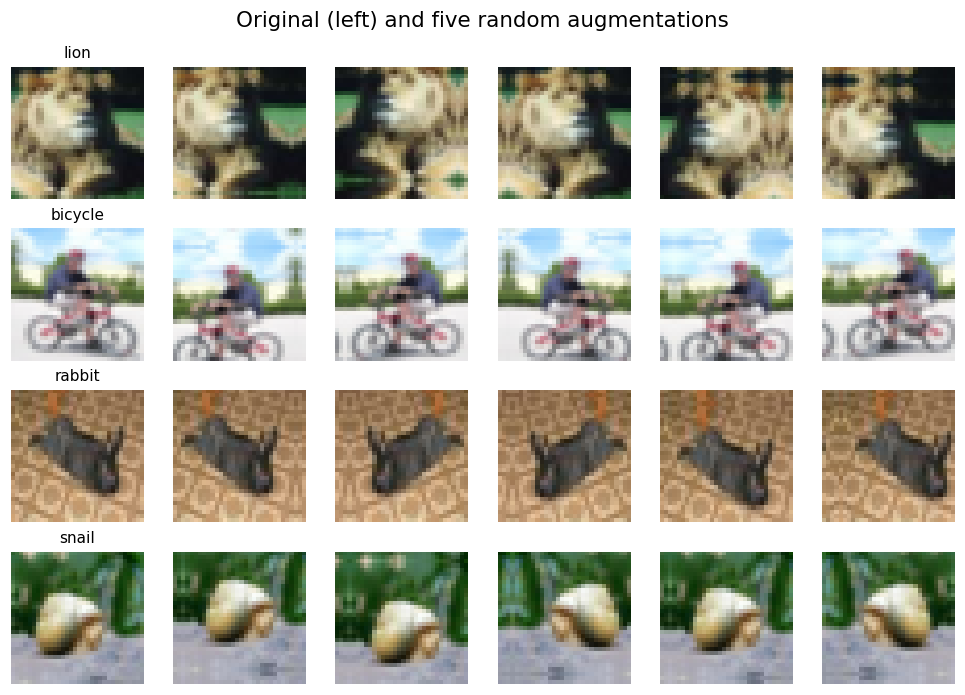

In [7]:
def show(image_tensor):
    # Undo normalization and move channels last for Matplotlib.
    image = image_tensor * channel_std[0] + channel_mean[0]
    return image.clamp(0, 1).permute(1, 2, 0).cpu().numpy()

examples = torch.from_numpy(np.random.default_rng(SEED).choice(len(x_train), size=4, replace=False)).to(device)
fig, axes = plt.subplots(4, 6, figsize=(9, 6.4))
for row, index in zip(axes, examples):
    original = normalize(train_images[index : index + 1])
    row[0].imshow(show(original[0]), interpolation="nearest")
    row[0].set_title(class_names[train_labels[index]].replace("_", " "), fontsize=10)
    for ax in row[1:]:
        ax.imshow(show(augment(original)[0]), interpolation="nearest")
    for ax in row:
        ax.axis("off")
fig.suptitle("Original (left) and five random augmentations", fontsize=14)
plt.tight_layout()
plt.show()

## 5. Build the CNN

We use a **ResNet-18**-style network adapted to 32 × 32 images (about 11 million parameters). Each convolution slides small 3 × 3 filters over the image to detect local patterns: edges and colors first, then textures and parts, then whole objects.

- **Residual blocks** add a block's input to its output (a "skip connection"). This makes deeper networks much easier to train.
- **Batch normalization** keeps the activations in a stable range during training.
- Four **stages** double the number of filters while halving the image size: 32 × 32 → 16 × 16 → 8 × 8 → 4 × 4.
- **Global average pooling** turns the final feature maps into one 512-number **embedding** per image, and a linear layer maps it to 100 class scores (**logits**).

The embeddings matter for this project: SDM measures similarity and distance in this feature space, so the model exposes them through `embed()`.

In [8]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.shortcut = nn.Identity()
        if stride != 1 or in_channels != out_channels:
            # Match the shape of the input so it can be added to the output.
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return F.relu(out + self.shortcut(x))


class CifarResNet(nn.Module):
    def __init__(self, num_classes=100, widths=(64, 128, 256, 512)):
        super().__init__()
        self.stem = nn.Sequential(nn.Conv2d(3, widths[0], 3, padding=1, bias=False), nn.BatchNorm2d(widths[0]), nn.ReLU())
        stages, in_channels = [], widths[0]
        for i, width in enumerate(widths):
            stride = 1 if i == 0 else 2
            stages.append(nn.Sequential(ResidualBlock(in_channels, width, stride), ResidualBlock(width, width)))
            in_channels = width
        self.stages = nn.Sequential(*stages)
        self.classifier = nn.Linear(widths[-1], num_classes)

    def embed(self, x):
        # The 512-dimensional feature vector before the final layer.
        return F.adaptive_avg_pool2d(self.stages(self.stem(x)), 1).flatten(1)

    def forward(self, x):
        return self.classifier(self.embed(x))


model = CifarResNet(num_classes=len(class_names)).to(device)
print(f"{sum(p.numel() for p in model.parameters()):,} trainable parameters")
with torch.no_grad():
    print("logits shape for 2 images:", tuple(model(normalize(train_images[:2])).shape))

11,220,132 trainable parameters
logits shape for 2 images: (2, 100)


## 6. Set up training

- **Loss:** cross-entropy, the standard loss for classification. We deliberately avoid *label smoothing*: it often raises accuracy but changes what the softmax confidence means, and confidence is what this project studies.
- **Optimizer:** stochastic gradient descent (SGD) with momentum and weight decay, a strong default for CNNs on CIFAR.
- **Learning-rate schedule:** the *one-cycle* schedule warms the learning rate up to `MAX_LR`, then lowers it to almost zero by the last epoch. This trains well in few epochs.

We keep the model from the **final epoch** instead of picking the epoch with the best validation accuracy. That way the validation set is not used to choose the model, and its results stay a fair estimate. The calibration set is not touched at all during training.

In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=MAX_LR, momentum=0.9, nesterov=True, weight_decay=WEIGHT_DECAY)
steps_per_epoch = (len(train_images) + BATCH_SIZE - 1) // BATCH_SIZE
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=MAX_LR, epochs=EPOCHS, steps_per_epoch=steps_per_epoch)


def train_one_epoch():
    model.train()
    order = torch.randperm(len(train_images), device=device)
    total_loss = total_correct = 0
    for start in range(0, len(order), BATCH_SIZE):
        batch = order[start : start + BATCH_SIZE]
        inputs, targets = augment(normalize(train_images[batch])), train_labels[batch]
        logits = model(inputs)
        loss = criterion(logits, targets)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()
        scheduler.step()
        total_loss += loss.item() * len(batch)
        total_correct += (logits.argmax(1) == targets).sum().item()
    return total_loss / len(order), total_correct / len(order)


@torch.no_grad()
def predict(images, batch_size=500):
    # Returns logits and embeddings for every image, on the CPU.
    model.eval()
    logits, embeddings = [], []
    for start in range(0, len(images), batch_size):
        features = model.embed(normalize(images[start : start + batch_size]))
        embeddings.append(features.cpu())
        logits.append(model.classifier(features).cpu())
    return torch.cat(logits), torch.cat(embeddings)

## 7. Train

Each epoch is one pass over the 45,000 training images. Watch the validation accuracy: it should rise quickly at first and keep improving as the learning rate drops at the end. Training accuracy is measured on *augmented* images, so it can sit below validation accuracy early on.

In [10]:
history = []
for epoch in range(1, EPOCHS + 1):
    start = time.time()
    train_loss, train_acc = train_one_epoch()
    val_logits, _ = predict(val_images)
    val_loss = F.cross_entropy(val_logits, val_labels.cpu()).item()
    val_acc = (val_logits.argmax(1) == val_labels.cpu()).float().mean().item()
    history.append({"epoch": epoch, "train loss": train_loss, "val loss": val_loss, "train acc": train_acc, "val acc": val_acc})
    print(f"epoch {epoch:2d}/{EPOCHS}  train loss {train_loss:.3f}  acc {train_acc:.1%}  |  "
          f"val loss {val_loss:.3f}  acc {val_acc:.1%}  |  {time.time() - start:.0f}s")
history = pd.DataFrame(history).set_index("epoch")

epoch  1/30  train loss 3.643  acc 14.4%  |  val loss 3.505  acc 18.8%  |  58s
epoch  2/30  train loss 2.826  acc 28.3%  |  val loss 2.771  acc 28.9%  |  57s
epoch  3/30  train loss 2.384  acc 36.8%  |  val loss 2.430  acc 36.0%  |  58s
epoch  4/30  train loss 2.091  acc 43.2%  |  val loss 2.434  acc 36.6%  |  57s
epoch  5/30  train loss 1.868  acc 48.3%  |  val loss 2.054  acc 44.8%  |  57s
epoch  6/30  train loss 1.684  acc 52.6%  |  val loss 1.905  acc 48.0%  |  57s
epoch  7/30  train loss 1.546  acc 56.1%  |  val loss 1.811  acc 50.8%  |  57s
epoch  8/30  train loss 1.440  acc 58.7%  |  val loss 1.789  acc 49.9%  |  57s
epoch  9/30  train loss 1.358  acc 60.9%  |  val loss 1.707  acc 54.1%  |  57s
epoch 10/30  train loss 1.271  acc 63.3%  |  val loss 1.606  acc 56.1%  |  57s
epoch 11/30  train loss 1.216  acc 64.6%  |  val loss 1.689  acc 54.3%  |  57s
epoch 12/30  train loss 1.161  acc 66.1%  |  val loss 1.669  acc 54.8%  |  58s
epoch 13/30  train loss 1.125  acc 67.1%  |  val los

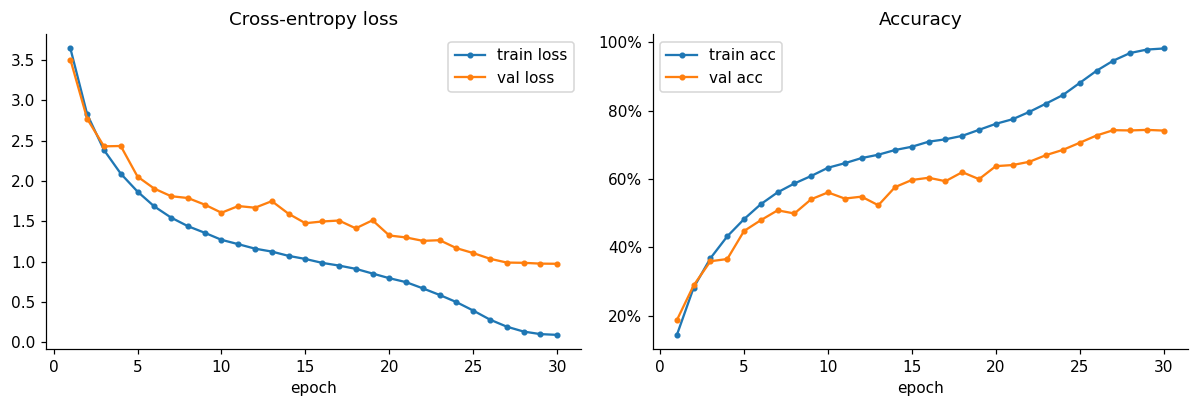

In [11]:
fig, (ax_loss, ax_acc) = plt.subplots(1, 2, figsize=(11, 3.8))
history[["train loss", "val loss"]].plot(ax=ax_loss, marker=".")
ax_loss.set_title("Cross-entropy loss")
history[["train acc", "val acc"]].plot(ax=ax_acc, marker=".")
ax_acc.set_title("Accuracy")
ax_acc.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1))
for ax in (ax_loss, ax_acc):
    ax.set_xlabel("epoch")
plt.tight_layout()
plt.show()

## 8. How accurate is the model?

**Top-1 accuracy** counts a prediction as right if the highest-scoring class is correct. **Top-5** counts it as right if the correct class is among the five highest. **Group accuracy** asks whether the predicted class at least falls in the correct broader group (for example *trees*), even if it is the wrong tree.

In [12]:
val_logits, val_embeddings = predict(val_images)
y_true = val_labels.cpu().numpy()
probs = val_logits.softmax(1).numpy()
y_pred = probs.argmax(1)
confidence = probs.max(1)
correct = y_pred == y_true

fine_to_group = np.zeros(len(class_names), dtype=int)
fine_to_group[all_labels] = all_groups  # every fine class belongs to exactly one group
top5 = np.argsort(-probs, axis=1)[:, :5]

pd.Series({
    "top-1 accuracy": f"{correct.mean():.1%}",
    "top-5 accuracy": f"{(top5 == y_true[:, None]).any(1).mean():.1%}",
    "group accuracy": f"{(fine_to_group[y_pred] == g_val).mean():.1%}",
    "mean confidence": f"{confidence.mean():.1%}",
}, name="validation").to_frame()

,validation
top-1 accuracy,74.2%
top-5 accuracy,93.2%
group accuracy,83.6%
mean confidence,82.0%


Accuracy varies a lot between classes. Which classes are easiest and hardest? Do the hard ones match what you expected from the EDA?

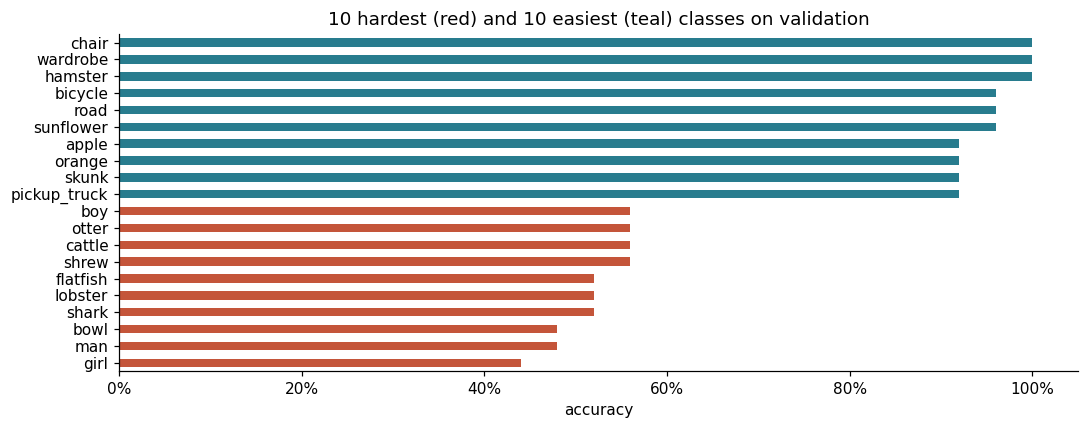

In [13]:
per_class = (
    pd.DataFrame({"class": np.array(class_names)[y_true], "correct": correct})
    .groupby("class")["correct"].mean().sort_values()
)
fig, ax = plt.subplots(figsize=(10, 4))
pd.concat([per_class.head(10), per_class.tail(10)]).plot.barh(
    ax=ax, color=["#c4553a"] * 10 + ["#287c8e"] * 10)
ax.set_title("10 hardest (red) and 10 easiest (teal) classes on validation")
ax.set_xlabel("accuracy")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1))
plt.tight_layout()
plt.show()

In the EDA we guessed that **maple** and **oak** would be confused. Let's check. The table shows where the validation images of each tree class ended up.

In [14]:
TREE_CLASSES = ["maple_tree", "oak_tree", "willow_tree", "pine_tree", "palm_tree"]
tree_ids = [class_names.index(name) for name in TREE_CLASSES]
rows = {}
for name, class_id in zip(TREE_CLASSES, tree_ids):
    predicted = y_pred[y_true == class_id]
    rows[name] = {other: (predicted == other_id).mean() for other, other_id in zip(TREE_CLASSES, tree_ids)}
    rows[name]["any other class"] = (~np.isin(predicted, tree_ids)).mean()
(pd.DataFrame(rows).T.rename_axis("true class \\ predicted")
   .style.format("{:.0%}").background_gradient(cmap="Blues", axis=None))

,maple_tree,oak_tree,willow_tree,pine_tree,palm_tree,any other class
true class \ predicted,,,,,,
maple_tree,76%,12%,8%,0%,0%,4%
oak_tree,4%,84%,4%,8%,0%,0%
willow_tree,8%,4%,84%,4%,0%,0%
pine_tree,0%,12%,8%,60%,4%,16%
palm_tree,0%,0%,4%,8%,80%,8%


## 9. Is the model calibrated?

The softmax probability of the predicted class is the model's **confidence**. A model is **calibrated** if its confidence matches how often it is right: of all the predictions made with 80% confidence, about 80% should be correct.

The **reliability diagram** groups predictions by confidence and compares each group's actual accuracy with the diagonal of perfect calibration. Bars below the diagonal mean the model is **overconfident**. The **expected calibration error (ECE)** is the average gap between confidence and accuracy, weighted by how many predictions fall in each bin.

We measure on the validation set, which the model never trained on.

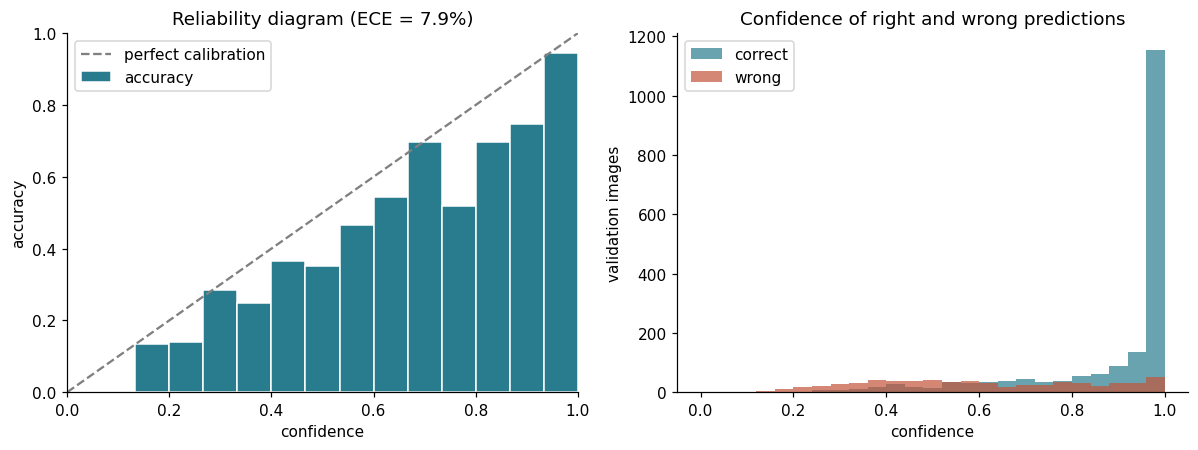

In [15]:
def calibration_bins(confidence, correct, n_bins=15):
    edges = np.linspace(0, 1, n_bins + 1)
    which = np.clip(np.digitize(confidence, edges[1:-1]), 0, n_bins - 1)
    table = pd.DataFrame({"bin": which, "confidence": confidence, "correct": correct}).groupby("bin").agg(
        count=("correct", "size"), confidence=("confidence", "mean"), accuracy=("correct", "mean"))
    ece = (table["count"] / len(confidence) * (table["confidence"] - table["accuracy"]).abs()).sum()
    return table, edges, ece


def reliability_diagram(ax, confidence, correct, title):
    table, edges, ece = calibration_bins(confidence, correct)
    ax.bar(edges[table.index], table["accuracy"], width=edges[1], align="edge", color="#287c8e", edgecolor="white", label="accuracy")
    ax.plot([0, 1], [0, 1], "--", color="gray", label="perfect calibration")
    ax.set(xlabel="confidence", ylabel="accuracy", title=f"{title} (ECE = {ece:.1%})", xlim=(0, 1), ylim=(0, 1))
    ax.legend(loc="upper left")


fig, (ax_rel, ax_hist) = plt.subplots(1, 2, figsize=(11, 4.2))
reliability_diagram(ax_rel, confidence, correct, "Reliability diagram")
bins = np.linspace(0, 1, 26)
ax_hist.hist(confidence[correct], bins=bins, alpha=0.7, color="#287c8e", label="correct")
ax_hist.hist(confidence[~correct], bins=bins, alpha=0.7, color="#c4553a", label="wrong")
ax_hist.set(xlabel="confidence", ylabel="validation images", title="Confidence of right and wrong predictions")
ax_hist.legend()
plt.tight_layout()
plt.show()

## 10. Temperature scaling: fixing the confidence after training

**Temperature scaling** divides every logit by one number, the temperature *T*, before the softmax:

- *T* > 1 flattens the probabilities, which lowers confidence and fixes **overconfidence**,
- *T* < 1 sharpens them, which fixes **underconfidence**,
- *T* = 1 changes nothing.

Dividing by a positive number never changes which class scores highest, so **accuracy stays exactly the same**. Only the confidence changes.

We choose *T* on the **calibration set** by minimizing the **negative log-likelihood (NLL)**: the average of −log(probability given to the true class). NLL is low when the model is confident and right, and it heavily punishes being confident and wrong, so the best *T* balances the two. We try a range of temperatures and keep the best one.

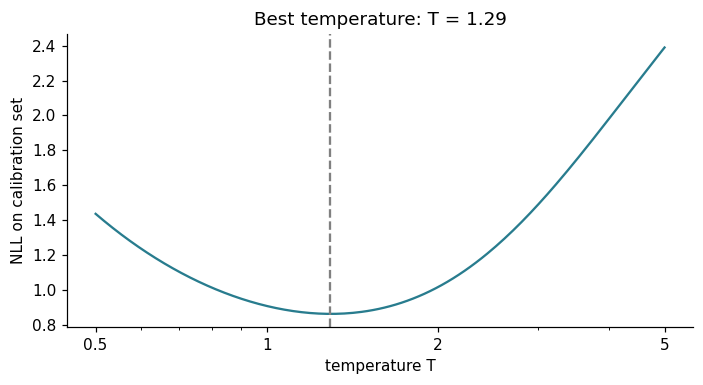

In [16]:
cal_logits, cal_embeddings = predict(cal_images)
cal_targets = cal_labels.cpu()

temperatures = np.exp(np.linspace(np.log(0.5), np.log(5), 200))
cal_nll = np.array([F.cross_entropy(cal_logits / t, cal_targets).item() for t in temperatures])
TEMPERATURE = float(temperatures[cal_nll.argmin()])

fig, ax = plt.subplots(figsize=(6.5, 3.6))
ax.plot(temperatures, cal_nll, color="#287c8e")
ax.axvline(TEMPERATURE, ls="--", color="gray")
ax.set(xscale="log", xlabel="temperature T", ylabel="NLL on calibration set",
       title=f"Best temperature: T = {TEMPERATURE:.2f}")
ax.set_xticks([0.5, 1, 2, 5], labels=["0.5", "1", "2", "5"])
ax.xaxis.set_minor_formatter(plt.NullFormatter())
plt.tight_layout()
plt.show()

Now apply that one temperature to the **validation** images, which played no part in choosing it, and compare before and after.

,accuracy,mean confidence,ECE,NLL
validation set,,,,
before (T = 1),74.2%,82.0%,7.9%,0.973
after (T = 1.29),74.2%,75.7%,2.7%,0.922


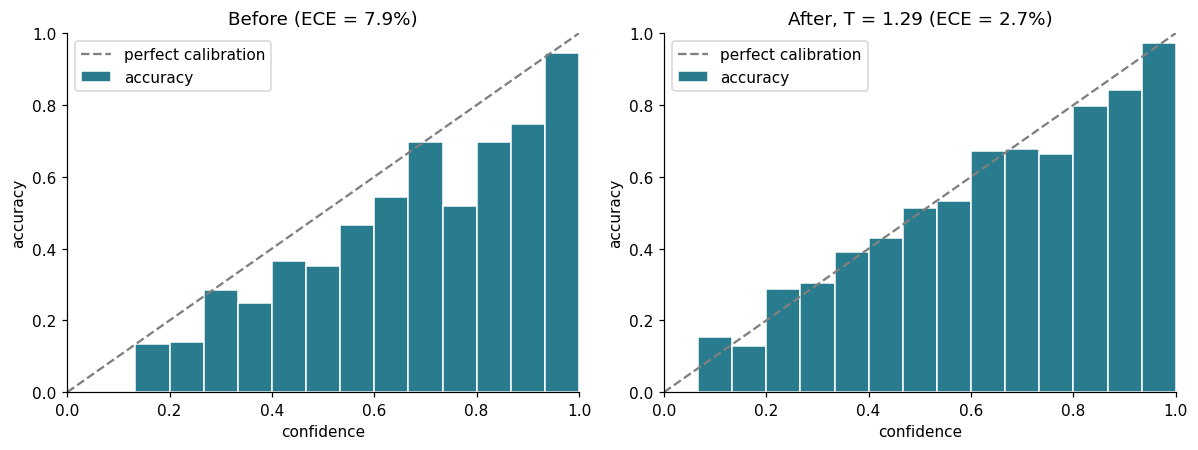

In [17]:
def softmax_confidence(logits, temperature=1.0):
    probs = (logits / temperature).softmax(1)
    return probs.max(1).values.numpy()

scaled_confidence = softmax_confidence(val_logits, TEMPERATURE)
before = calibration_bins(confidence, correct)[2], F.cross_entropy(val_logits, val_labels.cpu()).item()
after = calibration_bins(scaled_confidence, correct)[2], F.cross_entropy(val_logits / TEMPERATURE, val_labels.cpu()).item()

display(pd.DataFrame({
    "accuracy": [f"{correct.mean():.1%}"] * 2,
    "mean confidence": [f"{confidence.mean():.1%}", f"{scaled_confidence.mean():.1%}"],
    "ECE": [f"{before[0]:.1%}", f"{after[0]:.1%}"],
    "NLL": [f"{before[1]:.3f}", f"{after[1]:.3f}"],
}, index=["before (T = 1)", f"after (T = {TEMPERATURE:.2f})"]).rename_axis("validation set"))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
reliability_diagram(axes[0], confidence, correct, "Before")
reliability_diagram(axes[1], scaled_confidence, correct, f"After, T = {TEMPERATURE:.2f}")
plt.tight_layout()
plt.show()

**How to read this:** a model whose mean confidence is above its accuracy is overconfident, and the fitted *T* will be above 1. If *T* is close to 1, the model was already well calibrated. Temperature scaling is the standard simple baseline for calibration; SDM should be compared against the **temperature-scaled** model, not just the raw one.

## 11. Selective prediction: answer only when confident

The project's goal is a model that can **abstain**. The simplest rule: answer only if the (temperature-scaled) confidence is at least some threshold, otherwise say "I don't know".

- **Coverage** is the fraction of images the model answers.
- **Selective accuracy** is the accuracy on those answered images.

We want selective accuracy of at least `TARGET_ACCURACY` (95%) while answering as many images as possible. The honest way to do this has two steps:

1. **Choose** the threshold on the calibration set.
2. **Check** it on the validation set, which the threshold has never seen.

We compare two ways to choose the threshold:

- **plain**: the lowest threshold whose selective accuracy on calibration is at least 95%,
- **conservative**: the lowest threshold where even the *lower end of the 95% confidence interval* for selective accuracy is at least 95%. This allows for the fact that 2,500 calibration images are a limited sample.

Each validation result is reported with a 95% confidence interval (Wilson score interval), because 2,500 validation images also leave room for chance.

In [18]:
def wilson_interval(successes, n, z=1.96):
    # 95% confidence interval for a proportion; works on numbers or arrays.
    successes, n = np.asarray(successes, dtype=float), np.asarray(n, dtype=float)
    p = successes / n
    denominator = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / denominator
    half_width = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / denominator
    return center - half_width, center + half_width


def selective_curve(confidence, correct):
    # Coverage and selective accuracy when answering the k most confident images, for every k.
    order = np.argsort(-confidence)
    answered = np.arange(1, len(order) + 1)
    hits = np.cumsum(correct[order])
    return order, answered, hits


def choose_threshold(confidence, correct, target, conservative=False):
    order, answered, hits = selective_curve(confidence, correct)
    score = wilson_interval(hits, answered)[0] if conservative else hits / answered
    meets = np.flatnonzero(score >= target)
    return None if len(meets) == 0 else float(confidence[order][meets.max()])


def check_threshold(threshold, confidence, correct):
    answered = confidence >= threshold if threshold is not None else np.zeros(len(confidence), bool)
    n, k = answered.sum(), correct[answered].sum()
    low, high = wilson_interval(k, n) if n else (np.nan, np.nan)
    return {
        "threshold": "none reaches target" if threshold is None else f"{threshold:.3f}",
        "coverage": f"{answered.mean():.1%}",
        "images answered": int(n),
        "selective accuracy": f"{k / n:.1%}" if n else "-",
        "95% interval": f"{low:.1%} – {high:.1%}" if n else "-",
    }


cal_confidence = softmax_confidence(cal_logits, TEMPERATURE)
cal_correct = cal_logits.argmax(1).numpy() == y_cal
thresholds = {
    "plain": choose_threshold(cal_confidence, cal_correct, TARGET_ACCURACY),
    "conservative": choose_threshold(cal_confidence, cal_correct, TARGET_ACCURACY, conservative=True),
}

pd.DataFrame({
    f"{rule}, checked on validation": check_threshold(threshold, scaled_confidence, correct)
    for rule, threshold in thresholds.items()
}).T

,threshold,coverage,images answered,selective accuracy,95% interval
"plain, checked on validation",0.847,53.0%,1325,94.6%,93.2% – 95.7%
"conservative, checked on validation",0.905,46.0%,1151,96.1%,94.8% – 97.1%


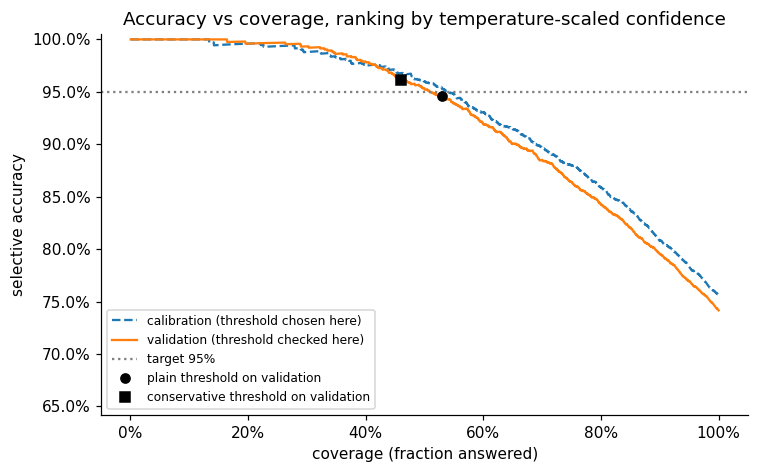

In [19]:
fig, ax = plt.subplots(figsize=(7, 4.4))
for name, conf, corr, style in [("calibration (threshold chosen here)", cal_confidence, cal_correct, "--"),
                                ("validation (threshold checked here)", scaled_confidence, correct, "-")]:
    _, answered, hits = selective_curve(conf, corr)
    ax.plot(answered / len(conf), hits / answered, style, label=name)
ax.axhline(TARGET_ACCURACY, ls=":", color="gray", label=f"target {TARGET_ACCURACY:.0%}")
for (rule, threshold), marker in zip(thresholds.items(), ["o", "s"]):
    if threshold is not None:
        answered = scaled_confidence >= threshold
        ax.plot(answered.mean(), correct[answered].mean(), marker, color="black", label=f"{rule} threshold on validation")
ax.set(xlabel="coverage (fraction answered)", ylabel="selective accuracy", ylim=(max(0, correct.mean() - 0.1), 1.005),
       title="Accuracy vs coverage, ranking by temperature-scaled confidence")
ax.xaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1))
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1))
ax.legend(fontsize=8, loc="lower left")
plt.tight_layout()
plt.show()

**What to look for:**

- The **plain** threshold is tuned to just reach 95% on the calibration images, so on new images it often lands slightly *below* 95%. The **conservative** threshold gives up some coverage to make that less likely.
- The coverage at 95% selective accuracy is the **baseline number SDM has to beat**: a better uncertainty method should answer more images at the same accuracy.
- None of this is a guarantee. It assumes new images look like the calibration images. Under corruption (CIFAR-100-C) or unfamiliar data (SVHN), the same threshold can fail badly, and that is exactly what the later experiments will test.

### The most confident mistakes

These are the wrong validation predictions the model was most sure about, after temperature scaling. For a reliability project, these are the most dangerous errors. Are some of them actually mislabeled, or ambiguous images?

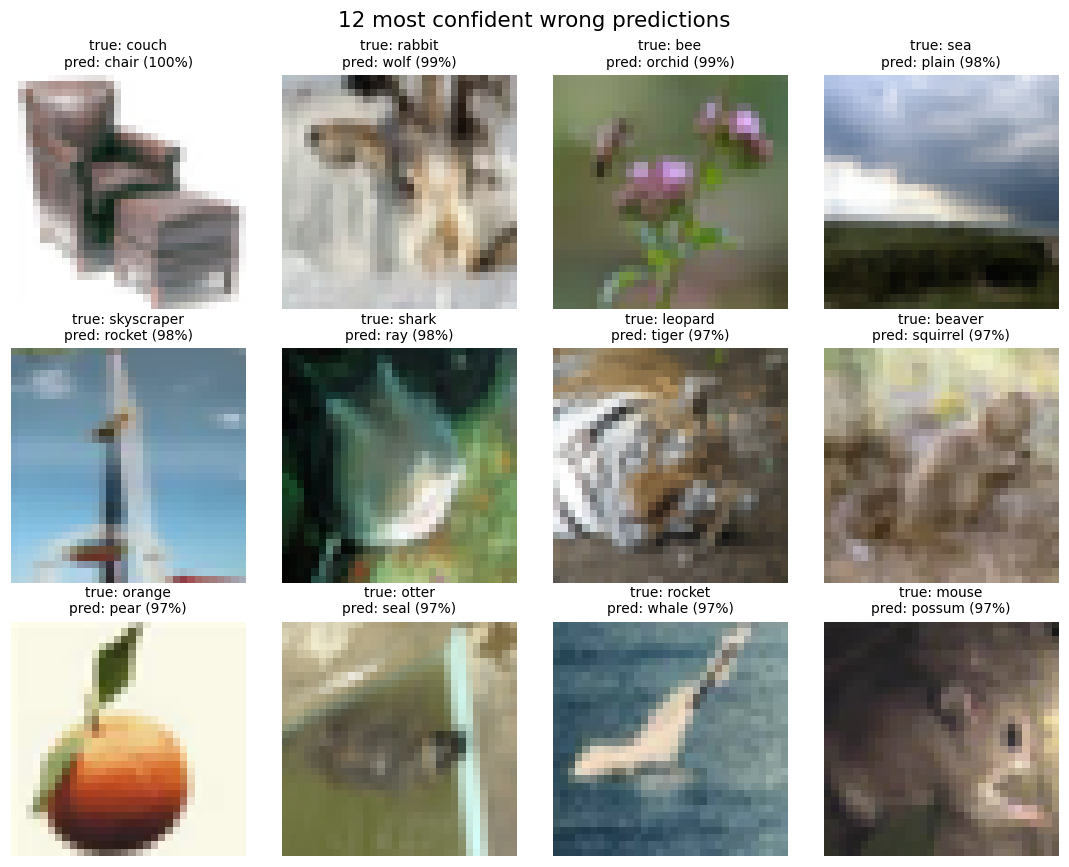

In [20]:
mistakes = np.flatnonzero(~correct)
worst = mistakes[np.argsort(-scaled_confidence[mistakes])][:12]

fig, axes = plt.subplots(3, 4, figsize=(10, 8))
for ax, i in zip(axes.flat, worst):
    ax.imshow(x_val[i].transpose(1, 2, 0), interpolation="nearest")
    ax.set_title(f"true: {class_names[y_true[i]]}\npred: {class_names[y_pred[i]]} ({scaled_confidence[i]:.0%})", fontsize=9)
    ax.axis("off")
fig.suptitle("12 most confident wrong predictions", fontsize=14)
plt.tight_layout()
plt.show()

## 12. Save the model and its outputs

We save to `outputs/` in the repository, which Git ignores.

- The **checkpoint** holds the model weights, normalization statistics, settings, split indices, the fitted temperature, and both thresholds, so another notebook can rebuild everything.
- The **`.npz` files** hold the validation and calibration logits, probabilities (before temperature scaling), embeddings, labels, predictions, and indices into the official training set. They use the same keys as the ConvNeXt baseline's exports, so later SDM code can load either model's outputs the same way.

In [21]:
OUTPUT_DIR = Path("../outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

torch.save({
    "model_state": model.state_dict(),
    "channel_mean": channel_mean.cpu(),
    "channel_std": channel_std.cpu(),
    "class_names": class_names,
    "split_indices": {"train": train_idx, "validation": val_idx, "calibration": cal_idx},
    "temperature": TEMPERATURE,
    "thresholds": thresholds,
    "settings": {"seed": SEED, "epochs": EPOCHS, "batch_size": BATCH_SIZE, "max_lr": MAX_LR,
                 "weight_decay": WEIGHT_DECAY, "target_accuracy": TARGET_ACCURACY},
    "history": history.to_dict(),
}, OUTPUT_DIR / "cifar100_resnet18.pt")


def save_outputs(path, logits, embeddings, targets, indices):
    np.savez_compressed(
        path, logits=logits.numpy(), probabilities=logits.softmax(1).numpy(), embeddings=embeddings.numpy(),
        targets=targets, predictions=logits.argmax(1).numpy(), class_names=np.array(class_names), dataset_indices=indices,
    )

save_outputs(OUTPUT_DIR / "cifar100_resnet18_validation_outputs.npz", val_logits, val_embeddings, y_val, val_idx)
save_outputs(OUTPUT_DIR / "cifar100_resnet18_calibration_outputs.npz", cal_logits, cal_embeddings, y_cal, cal_idx)
print("Saved:", *sorted(p.name for p in OUTPUT_DIR.iterdir() if p.name.startswith("cifar100_resnet18")), sep="\n  ")

Saved:
  cifar100_resnet18.pt
  cifar100_resnet18_calibration_outputs.npz
  cifar100_resnet18_validation_outputs.npz


## 13. Optional: final check on the test set

Run this only once the model and every setting are final; set `EVALUATE_TEST = True` at the top. It applies the temperature and thresholds fitted on the calibration set, unchanged, to the 10,000 official test images. If you look at test results and then change anything, the test set no longer gives an honest estimate.

In [22]:
if EVALUATE_TEST:
    x_test, y_test, _ = load_split("test")
    test_images, _ = to_device(x_test, y_test)
    test_logits, test_embeddings = predict(test_images)
    test_correct = test_logits.argmax(1).numpy() == y_test
    test_raw = softmax_confidence(test_logits)
    test_scaled = softmax_confidence(test_logits, TEMPERATURE)
    print(f"test accuracy {test_correct.mean():.1%}  |  ECE before {calibration_bins(test_raw, test_correct)[2]:.1%}, "
          f"after temperature scaling {calibration_bins(test_scaled, test_correct)[2]:.1%}")
    display(pd.DataFrame({f"{rule}, checked on test": check_threshold(threshold, test_scaled, test_correct)
                          for rule, threshold in thresholds.items()}).T)
    save_outputs(OUTPUT_DIR / "cifar100_resnet18_test_outputs.npz", test_logits, test_embeddings, y_test, np.arange(len(y_test)))
else:
    print("Skipped: the test set stays untouched (set EVALUATE_TEST = True to run).")

Skipped: the test set stays untouched (set EVALUATE_TEST = True to run).


## 14. Questions for the team

Write your observations here.

1. Which classes are hardest? Are they the ones the EDA suggested (similar colors, similar shapes, same broader group)?
2. Was the model over- or underconfident? What temperature was fitted, and how much did it reduce the ECE?
3. Did the plain threshold reach 95% on validation? How much coverage did the conservative threshold give up?
4. Look at the most confident mistakes. Which are true model errors, and which are ambiguous or mislabeled images?
5. The coverage at 95% selective accuracy is the number SDM needs to improve. How does it compare with the ConvNeXt baseline on the same calibration and validation images?